# Задача 1: Предвиждане на температурата на атмосферния въздух

## **Данни**

Дадените СSV файлове предоставят атмосферни данни от 1 януари 2013 г. до 24 април 2017 г. в град Делхи, Индия. Данните съдържат следните параметри:
- **date** - дата във хормат YYYY-MM-DD,
- **meantemp** - средна температура за деня,
-  **humidity** - влажност на въздуха,
- **wind_speed** - скорост на вятъра, измерена в км/ч,
- **meanpressure** - средно атмосферно налягане.

Данните са разделени на тренировъчно и тестово множество.

### Тренировъчно множество

 `daily_climate_train.csv` - съдържа данни от 1 януари 2013 г. до 31 декември 2016 г.

### Тестово множество

`daily_climate_temp.csv` - съдържа данни от 1 януари 2017 г. до 24 април 2017 г. Не съдържа променливата **meantemp**, която трябва да се предвиди.


## **Задача**

Целта на задачата е да обучите регресор, базиран на случайна гора (**Random Forest Regressor**), който да предвижда температурата на базата на **измерените стойности на показателите от предишните дни**.

При съставянето на решението си помислете:
- Какви времеви характеристики можем да извлечем от данните?
- Какви параметри да оптимизираме на случайната гора и как?


### **Оценка**

За оценка на решението ще използваме средна квадратична грешка (MSE - mean square error). При тази метрика **по-ниските стойности означават по-добър модел**.


In [ ]:
!pip install gdown

In [5]:
!gdown 1vUS7Lkl58v6LMmnnApU19QSekmq2FM09  # Сваляне на тренировъчните данни

Downloading...
From: https://drive.google.com/uc?id=1vUS7Lkl58v6LMmnnApU19QSekmq2FM09
To: /content/daily_climate_train.csv
100% 78.1k/78.1k [00:00<00:00, 68.5MB/s]


In [6]:
!gdown 1SqRec48Gb_UlnLvJ6zDK9oAiKDc4xy-A # Сваляне на тренировъчните данни

Downloading...
From: https://drive.google.com/uc?id=1SqRec48Gb_UlnLvJ6zDK9oAiKDc4xy-A
To: /content/daily_climate_test.csv
100% 5.79k/5.79k [00:00<00:00, 19.2MB/s]


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
import os

In [ ]:
os.listdir()

['.config', 'daily_climate_train.csv', 'daily_climate_test.csv', 'sample_data']

In [8]:
df_train = pd.read_csv("daily_climate_train.csv")
df_train.head(3)

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.5,0.000000,1015.666667
1,2013-01-02,7.400000,92.0,2.980000,1017.800000
2,2013-01-03,7.166667,87.0,4.633333,1018.666667


In [ ]:
df_train.tail(3)

,date,meantemp,humidity,wind_speed,meanpressure
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [ ]:
# Общи статистики на данните
df_train.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,25.506127,60.744851,6.806865,1011.101197
std,7.339416,16.743928,4.559688,180.293335
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.571429
50%,27.714286,62.625000,6.250000,1008.555556
75%,31.312500,72.125000,9.250000,1014.937500
max,38.714286,98.000000,42.220000,7679.333333


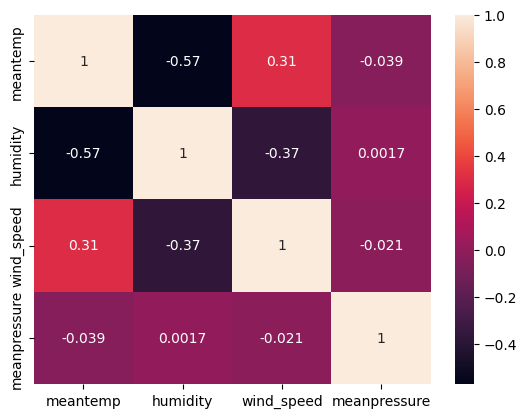

In [ ]:
# Корелационна матрица
correlation_mat = df_train.select_dtypes('number').corr()
fig, ax = plt.subplots()
sns.heatmap(correlation_mat, annot = True, ax=ax)
plt.show()

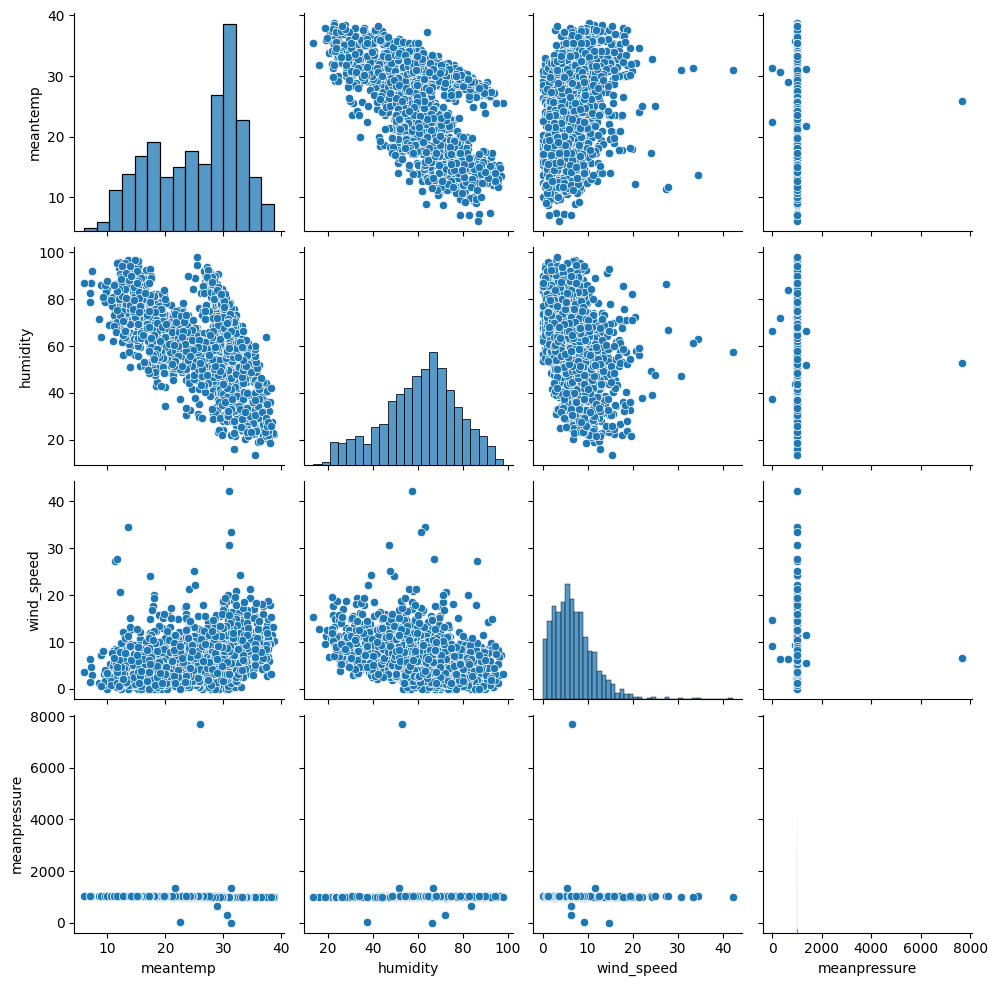

In [ ]:
# Разпределения и взаимни разпределения на данните
sns.pairplot(df_train)

In [9]:
df_test = pd.read_csv("daily_climate_test.csv")
df_test.head()

,date,humidity,wind_speed,meanpressure
0,2017-01-01,85.869565,2.743478,59.000000
1,2017-01-02,77.222222,2.894444,1018.277778
2,2017-01-03,81.888889,4.016667,1018.333333
3,2017-01-04,70.050000,4.545000,1015.700000
4,2017-01-05,74.944444,3.300000,1014.333333


In [ ]:
# Започнете решението си тук

In [10]:
# Съставяне на характеристики
# Добавете допълнителни характеристики към данните тук

for df in [df_train, df_test]:
    df['date'] = pd.to_datetime(df['date'])
    # df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
    df['wind_speed'] = df['wind_speed'].clip(lower=0, upper=df['wind_speed'].quantile(0.99))
    # df['day'] = df['date'].dt.day
    # df['dayofweek'] = df['date'].dt.dayofweek
    # df['dayofyear'] = df['date'].dt.dayofyear
    # df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    # df['humidity_roll3'] = df['humidity'].rolling(3).mean()
    # df['wind_roll3'] = df['wind_speed'].rolling(3).mean()

from scipy import stats

z_scores = np.abs(stats.zscore(df[['humidity', 'wind_speed', 'meanpressure']]))
df = df[(z_scores < 3).all(axis=1)]

#df_train.drop(columns='meanpressure', inplace=True)
#df_test.drop(columns='meanpressure', inplace=True)

"""
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
"""

# === 5. Добавяне на лагови характеристики към train ===
"""
for lag in [1, 2, 3]:
    for col in ['humidity', 'wind_speed']:
        df_train[f'{col}_lag{lag}'] = df_train[col].shift(lag)
        df_test[f'{col}_lag{lag}'] = df_test[col].shift(lag)

df_train = df_train.dropna().reset_index(drop=True)

"""

# === 6. Подготовка на train множества ===
y_train = df_train['meantemp']
X_train = df_train.drop(columns=['meantemp', 'date'])


# === 3. Drop rows with NaN (lagged rows) ===
df_train = df_train.dropna().reset_index(drop=True)
df_test = df_test.dropna().reset_index(drop=True)

# === 4. Separate features and target ===
y_train = df_train['meantemp']
X_train = df_train.drop(columns=['meantemp', 'date'])

X_test = df_test.drop(columns=['date'])

In [11]:
# Съставяне на тренировъчно множество
# Не променяйте този код!

# Премахване на колоната date, тъй като RandomForestRegressor не поддържа формата
df_train.drop(columns='date', inplace=True)

X_train = df_train.drop('meantemp', axis=1)
y_train = df_train['meantemp']

In [12]:
# Разделяне на данните за кросвалидация
tscv = TimeSeriesSplit(n_splits=5)

In [13]:
# Създаване на мрежа за търсене на хиперпараметри
param_grid = {
    """
    'n_estimators': [80,100,150], # 50,200
    'max_depth': [15,20],
    'min_samples_split': [5, 6],
    'min_samples_leaf': [2],
    'max_features': ['sqrt', 'log2']
    """
    # променете стойностите и/или добавете още хиперпараметри тук
}
param_dist = {
    'n_estimators': [ 70, 80, 90, 95, 100, 110],
    'max_depth': [11, 13, 14, 17, 18],
    'min_samples_split': [4, 5, 6, 9],
    'min_samples_leaf': [1, 2],
    'max_features': ['log2', 0.4, 0.5, 0.6, 0.7],
    'ccp_alpha': [0.0, 0.001, 0.005],
    'min_impurity_decrease': [0.0, 0.01, 0.02],
    'max_leaf_nodes': [None, 30, 50]

}

In [14]:
# Иницииране на оценяваща функция и модел
# Не променяйте този код!
scorer = make_scorer(mean_squared_error, greater_is_better=False)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

In [15]:
# Настройка на хирепараметри

"""
grid_search = GridSearchCV(estimator=rf,
                          param_grid=param_grid,
                          cv=tscv,
                          scoring=scorer,
                          n_jobs=-1,
                          verbose=1)
grid_search.fit(X_train, y_train)
"""
from sklearn.model_selection import RandomizedSearchCV

grid_search = RandomizedSearchCV(rf,
                            param_distributions=param_dist,
                            n_iter=400,       # try random combos
                            scoring=scorer,
                            cv=tscv,
                            verbose=1,
                            random_state=42,
                            n_jobs=-1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=400, n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.0, 0.001, 0.005],
                                        'max_depth': [11, 13, 14, 17, 18],
                                        'max_features': ['log2', 0.4, 0.5, 0.6,
                                                         0.7],
                                        'max_leaf_nodes': [None, 30, 50],
                                        'min_impurity_decrease': [0.0, 0.01,
                                                                  0.02],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [4, 5, 6, 9],
                                        'n_estimators': [70, 80, 90, 95, 100,
                                                         110]},
                   random_state=42,
                   scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'),
                   verbose=1)

In [16]:
# Избор на модел
# Не променяйте този код!
model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(grid_search.best_score_)

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'min_impurity_decrease': 0.0, 'max_leaf_nodes': None, 'max_features': 'log2', 'max_depth': 13, 'ccp_alpha': 0.005}
-4.462397667467233


In [17]:
# Добавете същите характеристики и върху тестовото множество
# Броят колони в X_test трябва да е същият, както в X_train
X_test = df_test.copy()
# Добавете тук
# правя го горе заедно с training dataset-а


In [18]:
# Предвиждане върху тестовото множество
# Не променяйте този код!
X_test.drop(columns='date', inplace=True)
predictions = model.predict(X_test)

submission_df = pd.DataFrame({'predictions': predictions})

In [20]:
# Запазване на предвижданията във файл submission_task1_FirstName_LastName.csv
# СМЕНЕТЕ С ВАШИТЕ ИМЕНА!
FIRST_NAME = "Reni"
LAST_NAME = "Paskaleva"

submission_df.to_csv(f'submission_task_1_{FIRST_NAME}_{LAST_NAME}.csv', index=False)